# Heart Disease UCI Dataset — Exploratory Data Analysis

This notebook performs comprehensive data acquisition, cleaning, and exploratory analysis
of the **Heart Disease UCI dataset** as required by **Task 1** of the MLOps Assignment.

**Objectives:**
- Obtain and load the dataset with download instructions
- Clean and preprocess the data (handle missing values, duplicates, encode features)
- Perform professional EDA with visualizations (histograms, correlation heatmaps, class balance, pair plots, violin plots)
- Document key findings to guide model development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

## 1. Data Acquisition & Loading

### Dataset Source
- **Title:** Heart Disease UCI Dataset
- **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/heart+Disease)
- **Alternative:** [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/ronitf/heart-disease-uci)

### Download Instructions
```bash
# Option 1: Direct download from Kaggle (requires kaggle CLI)
kaggle datasets download -d ronitf/heart-disease-uci -p data/ --unzip

# Option 2: The dataset is already included in data/heart.csv
```

In [2]:
DATA_PATH = Path("../data/heart.csv")
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(10)

Dataset Shape: 303 rows x 14 columns
Memory Usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2. Data Dictionary

| Feature | Description | Type | Values |
|---------|-------------|------|--------|
| `age` | Age in years | Continuous | 29-77 |
| `sex` | Biological sex | Binary | 0 = Female, 1 = Male |
| `cp` | Chest pain type | Categorical | 1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain, 4 = Asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg) | Continuous | 94-200 |
| `chol` | Serum cholesterol (mg/dl) | Continuous | 126-564 |
| `fbs` | Fasting blood sugar > 120 mg/dl | Binary | 0 = No, 1 = Yes |
| `restecg` | Resting ECG results | Categorical | 0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy |
| `thalach` | Maximum heart rate achieved | Continuous | 71-202 |
| `exang` | Exercise-induced angina | Binary | 0 = No, 1 = Yes |
| `oldpeak` | ST depression induced by exercise | Continuous | 0-6.2 |
| `slope` | Slope of peak exercise ST segment | Categorical | 1 = Upsloping, 2 = Flat, 3 = Downsloping |
| `ca` | Number of major vessels colored by fluoroscopy | Discrete | 0-3 |
| `thal` | Thalassemia | Categorical | 3 = Normal, 6 = Fixed defect, 7 = Reversible defect |
| `target` | Heart disease diagnosis | Binary | 0 = No disease, 1 = Disease |

## 3. Data Quality Assessment

In [3]:
df.info()
print(f"\nDataset dtypes:\n{df.dtypes.value_counts()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Dataset dtypes:
float64    13
int64       1
Name: count, dtype: int64


### 3.1 Missing Values Analysis

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print("Columns with missing values:")
    print(missing_df)
    print(f"\nTotal missing values: {df.isnull().sum().sum()} ({df.isnull().sum().sum() / df.size * 100:.3f}% of all data)")
else:
    print("No missing values found!")

print(f"\nMissing values per column:")
print(df.isnull().sum())

Columns with missing values:
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66

Total missing values: 6 (0.141% of all data)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


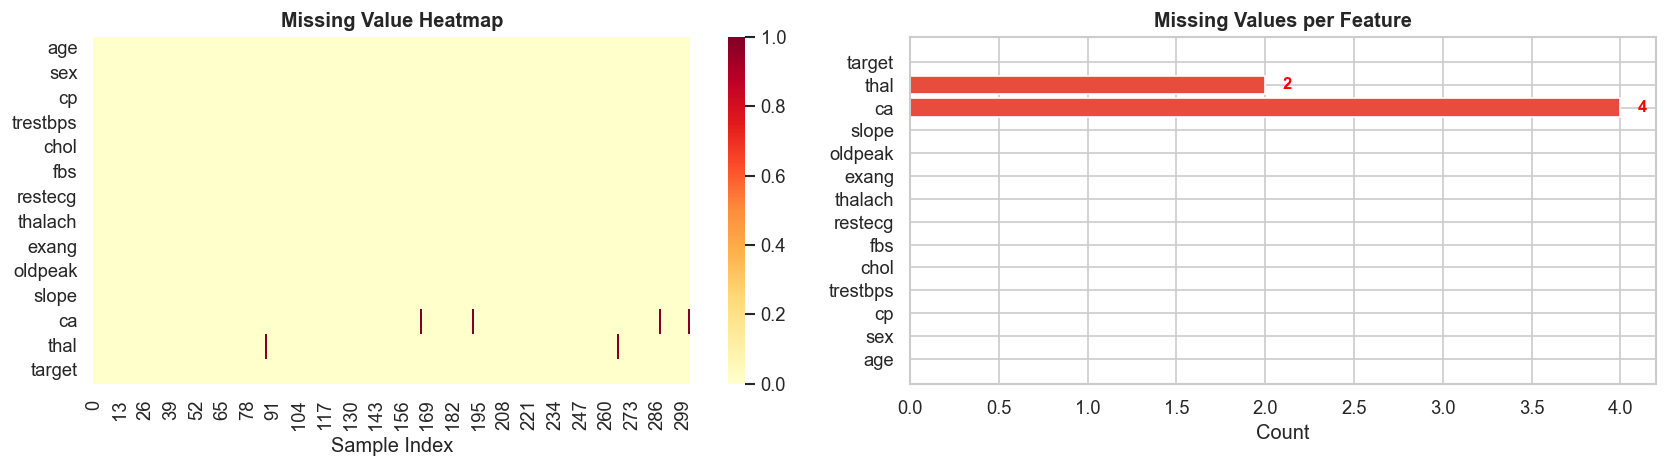

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(df.isnull().T, cbar=True, yticklabels=True, ax=axes[0], cmap='YlOrRd')
axes[0].set_title('Missing Value Heatmap', fontweight='bold')
axes[0].set_xlabel('Sample Index')

missing_counts = df.isnull().sum()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_counts]
axes[1].barh(missing_counts.index, missing_counts.values, color=colors)
axes[1].set_title('Missing Values per Feature', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(missing_counts.values):
    if v > 0:
        axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('../screenshots/missing_values.png', bbox_inches='tight')
plt.show()

In [6]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"  Filled '{col}' with median = {median_val}")
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  Filled '{col}' with mode = {mode_val}")

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")

  Filled 'ca' with median = 0.0
  Filled 'thal' with median = 3.0

Missing values after cleaning: 0


### 3.2 Duplicate Detection

In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {duplicates / len(df) * 100:.2f}%")
    print("\nRemoving duplicates...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found - dataset is clean.")

Number of duplicate rows: 0
No duplicates found - dataset is clean.


## 4. Statistical Summary

In [8]:
summary = df.describe().T
summary['skewness'] = df.skew(numeric_only=True)
summary['kurtosis'] = df.kurtosis(numeric_only=True)
summary['IQR'] = summary['75%'] - summary['25%']
summary.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0,-0.209,-0.523,13.0
sex,303.0,0.680,0.467,0.0,0.0,1.0,1.0,1.0,-0.775,-1.409,1.0
cp,303.0,3.158,0.960,1.0,3.0,3.0,4.0,4.0,-0.842,-0.401,1.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0,0.706,0.880,20.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0,1.136,4.492,64.0
fbs,303.0,0.149,0.356,0.0,0.0,0.0,0.0,1.0,1.987,1.960,0.0
restecg,303.0,0.990,0.995,0.0,0.0,1.0,2.0,2.0,0.020,-1.999,2.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0,-0.537,-0.054,32.5
exang,303.0,0.327,0.470,0.0,0.0,0.0,1.0,1.0,0.743,-1.458,1.0
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2,1.270,1.576,1.6


### 4.1 Distribution Skewness Analysis

In [9]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print("Feature Skewness (|skew| > 0.5 indicates non-normality):")
print("=" * 50)
for feat, skew_val in skewness.items():
    indicator = "SKEWED" if abs(skew_val) > 0.5 else "Normal"
    print(f"  {feat:12s}: {skew_val:7.3f}  ({indicator})")

Feature Skewness (|skew| > 0.5 indicates non-normality):
  fbs         :   1.987  (SKEWED)
  oldpeak     :   1.270  (SKEWED)
  ca          :   1.209  (SKEWED)
  chol        :   1.136  (SKEWED)
  exang       :   0.743  (SKEWED)
  trestbps    :   0.706  (SKEWED)
  slope       :   0.508  (SKEWED)
  thal        :   0.256  (Normal)
  target      :   0.166  (Normal)
  restecg     :   0.020  (Normal)
  age         :  -0.209  (Normal)
  thalach     :  -0.537  (SKEWED)
  sex         :  -0.775  (SKEWED)
  cp          :  -0.842  (SKEWED)


## 5. Target Variable Analysis

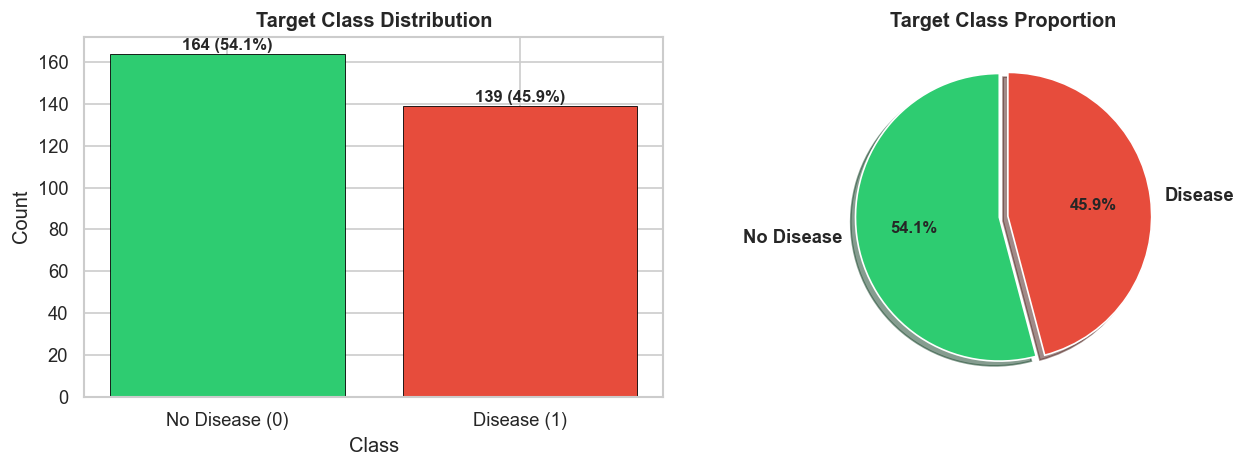


Class balance ratio: 0.848 (1.0 = perfectly balanced)
Dataset is well-balanced.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(counts.index.map({0: 'No Disease (0)', 1: 'Disease (1)'}),
                   counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
    colors=colors, startangle=90, explode=(0.03, 0.03),
    textprops={'fontweight': 'bold'}, shadow=True
)
axes[1].set_title('Target Class Proportion', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../screenshots/class_balance.png', bbox_inches='tight')
plt.show()

majority = counts.max()
minority = counts.min()
print(f"\nClass balance ratio: {minority/majority:.3f} (1.0 = perfectly balanced)")
print(f"Dataset is {'well-balanced' if minority/majority > 0.8 else 'moderately balanced'}.")

## 6. Feature Distributions (Histograms + KDE)

Examining the distribution of continuous features, colored by target class to identify separability.

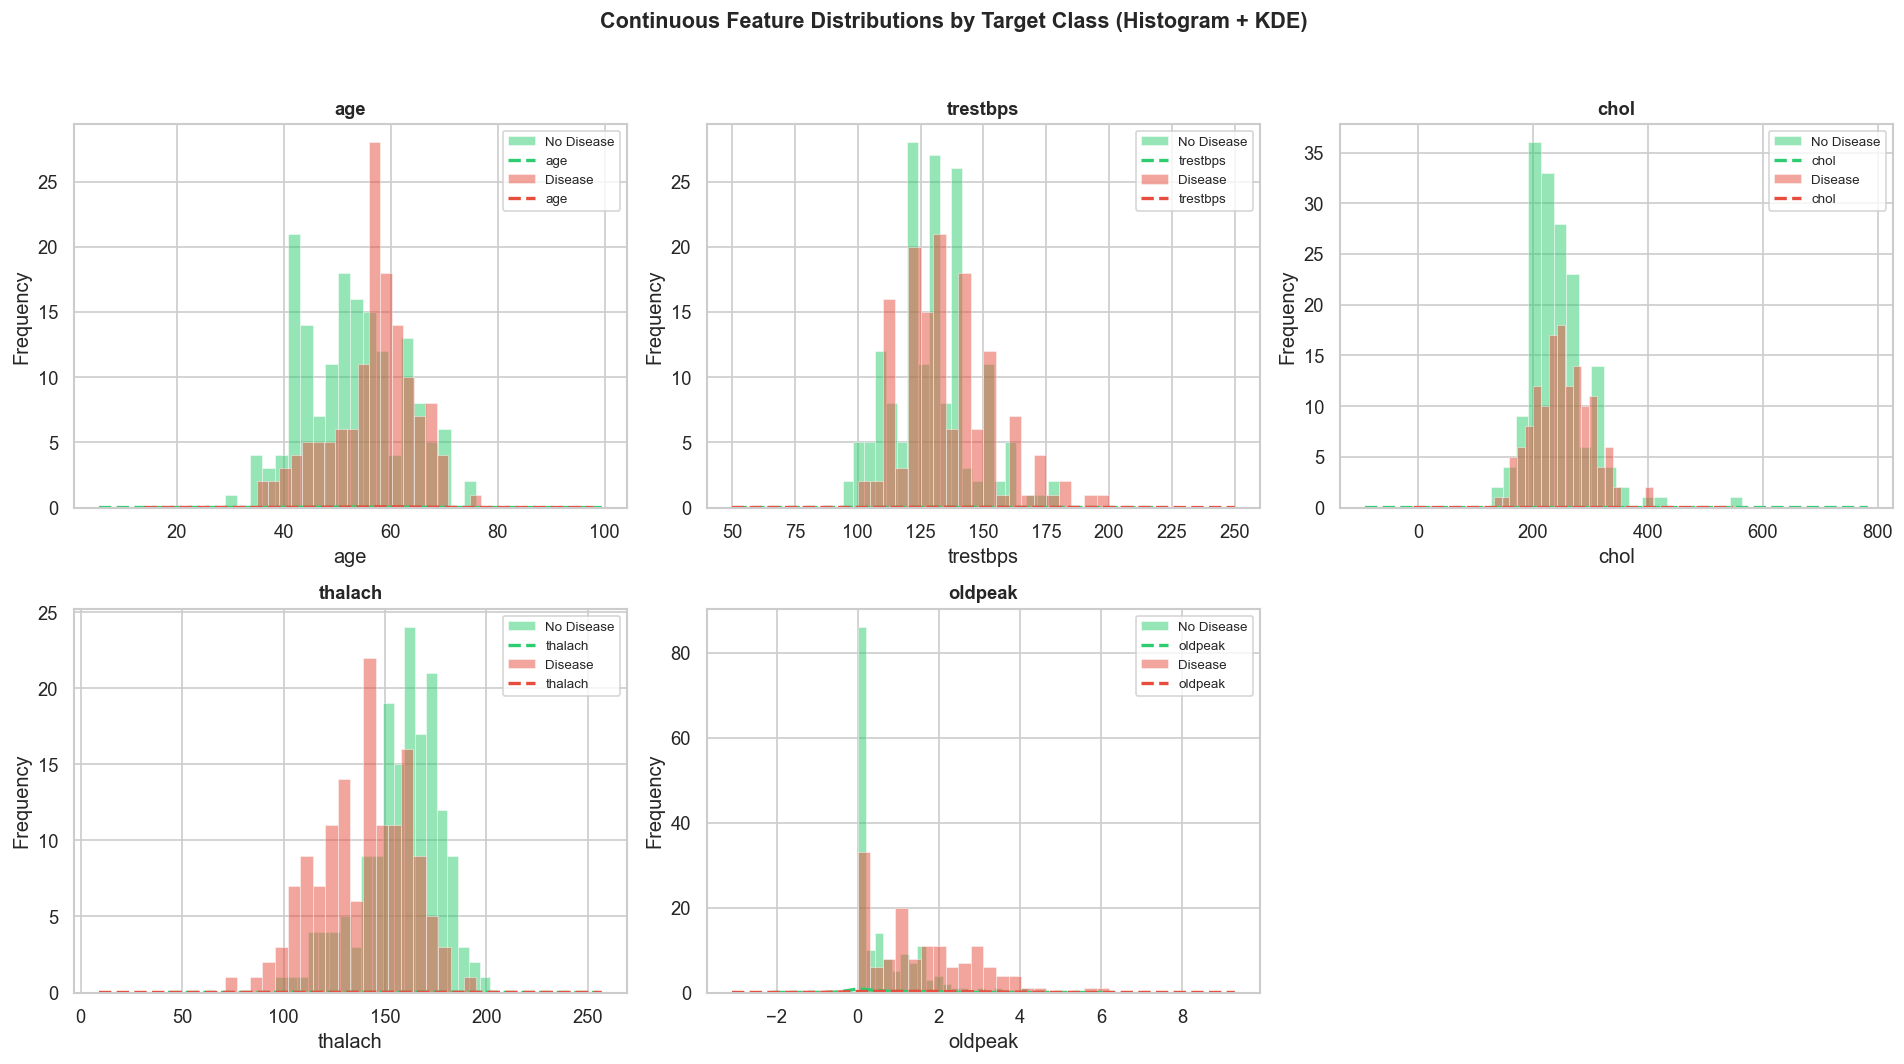

In [11]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    ax = axes[i]
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Disease', 'Disease']):
        subset = df[df['target'] == label][col]
        ax.hist(subset, bins=20, alpha=0.5, color=color, label=name,
                edgecolor='white', linewidth=0.5)
        subset.plot.kde(ax=ax, color=color, linewidth=2, linestyle='--')
    ax.set_title(f'{col}', fontweight='bold', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].axis('off')
plt.suptitle('Continuous Feature Distributions by Target Class (Histogram + KDE)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../screenshots/feature_histograms.png', bbox_inches='tight')
plt.show()

### 6.1 Violin Plots — Distribution Shape Comparison

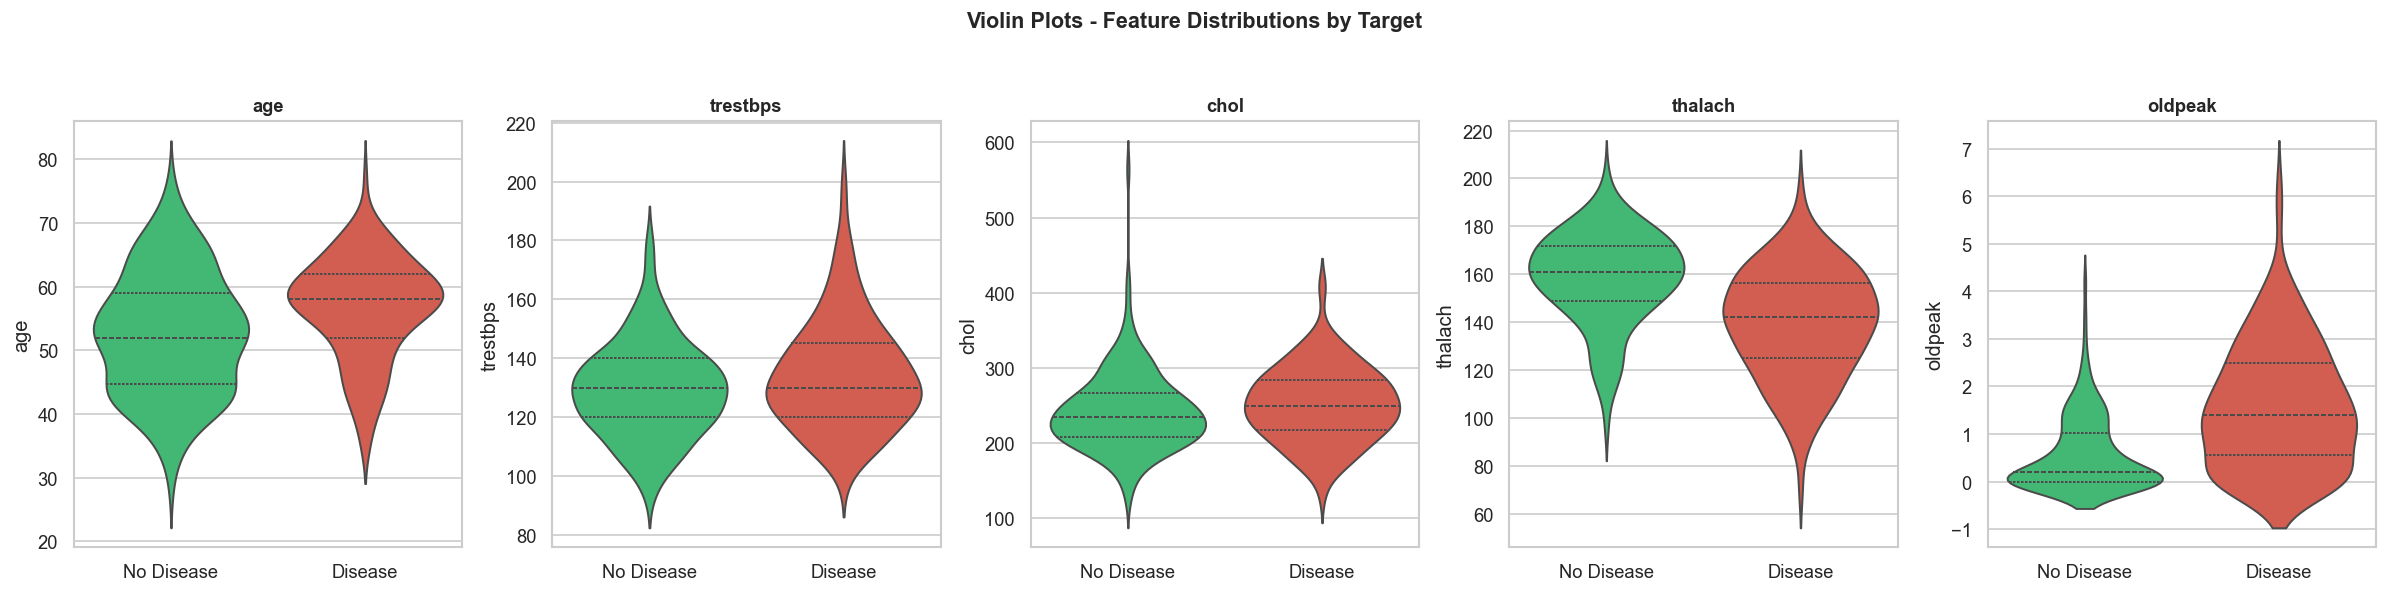

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(continuous_features):
    sns.violinplot(data=df, x='target', y=col, ax=axes[i], hue='target',
                   palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False,
                   inner='quartile', linewidth=1.2)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots - Feature Distributions by Target', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../screenshots/violin_plots.png', bbox_inches='tight')
plt.show()

## 7. Categorical Feature Analysis

Examining how categorical features relate to heart disease presence using stacked proportion bars.

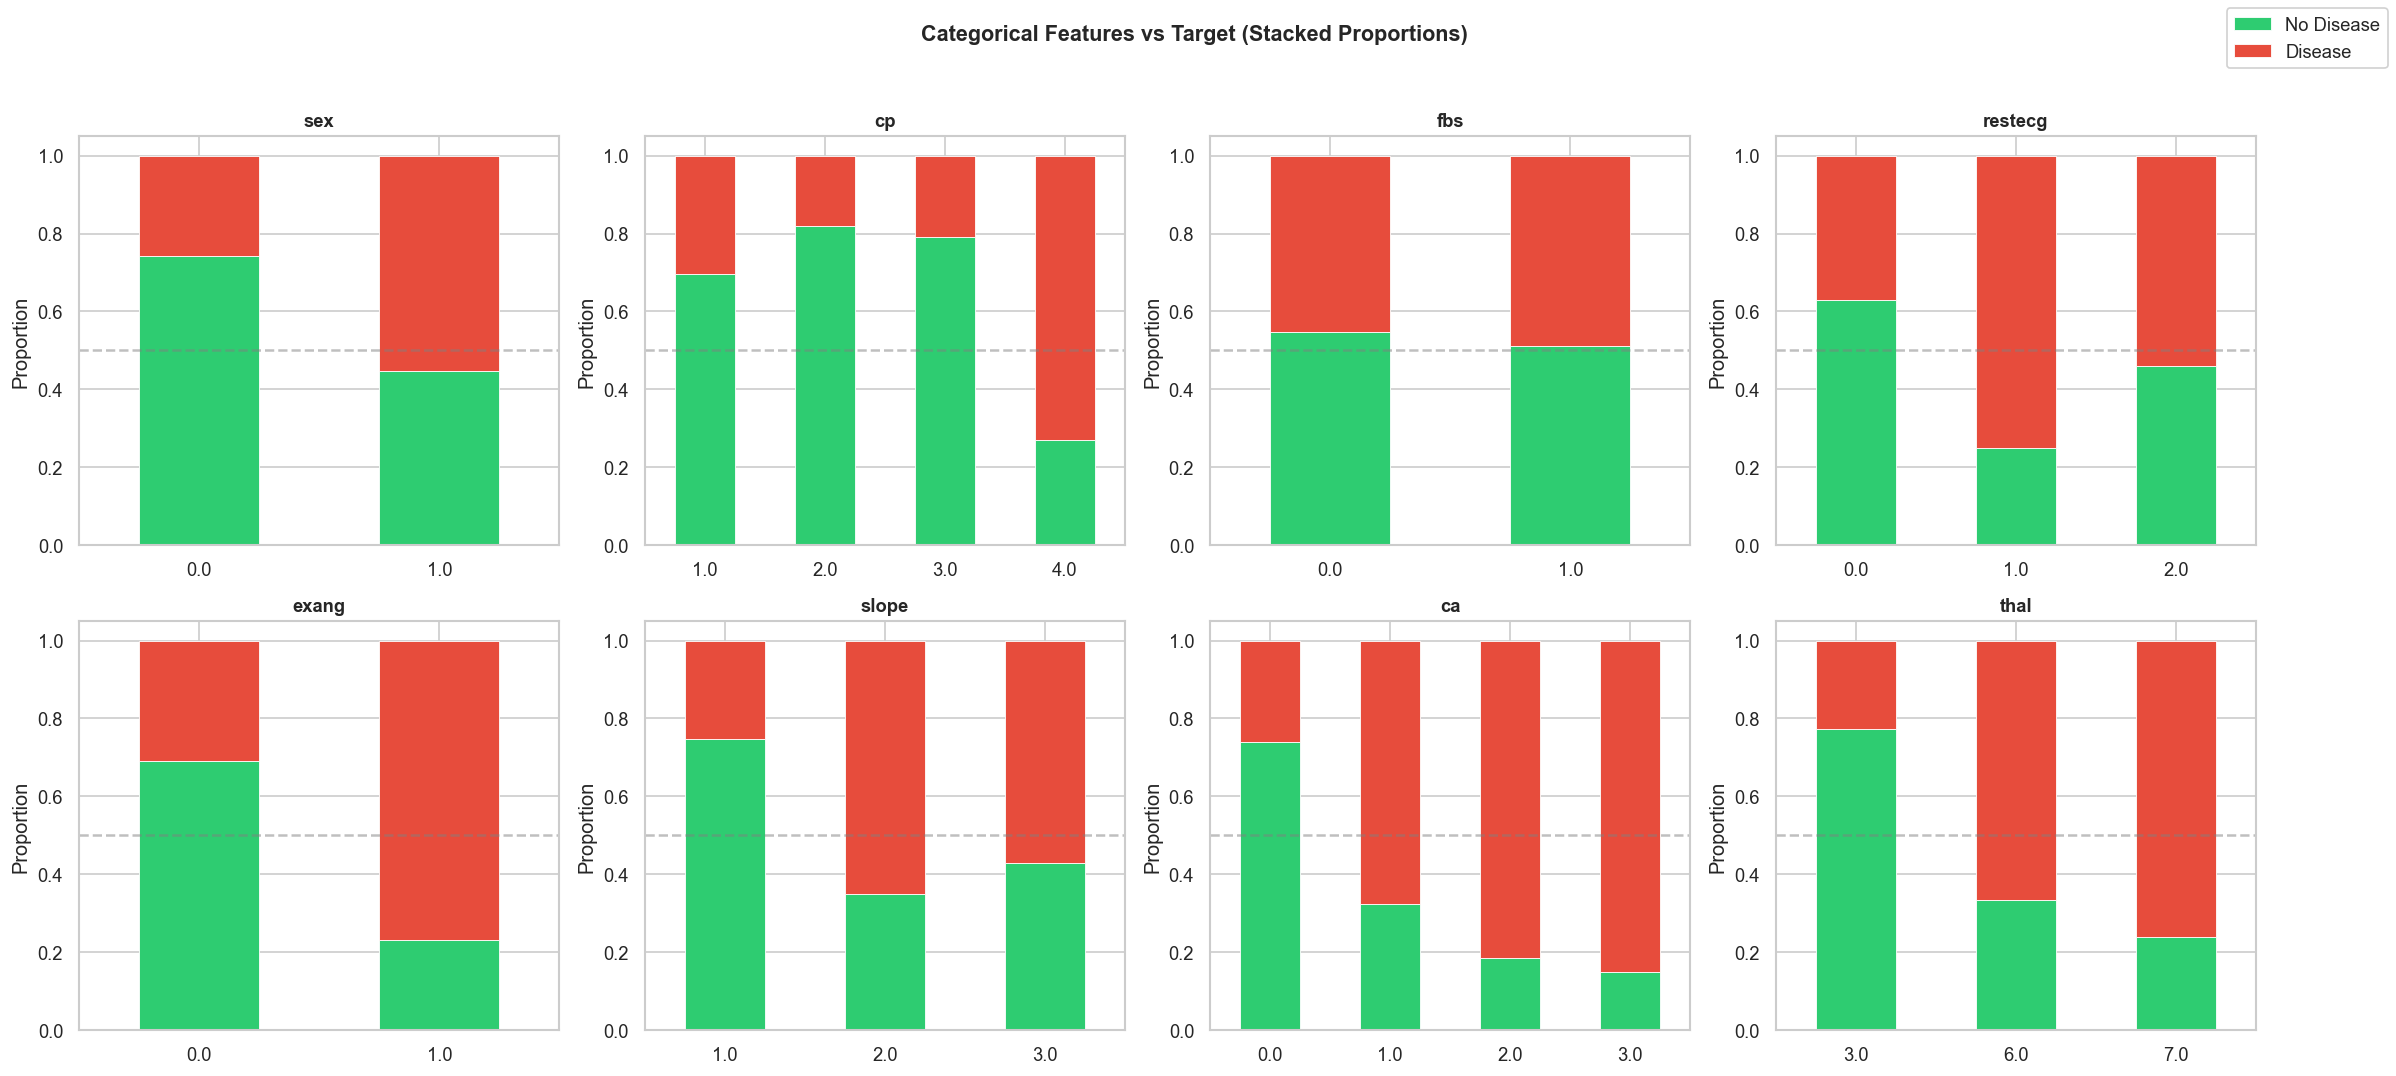

In [13]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], legend=False,
            edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Disease', 'Disease'], loc='upper right', fontsize=11, framealpha=0.9)
plt.suptitle('Categorical Features vs Target (Stacked Proportions)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.savefig('../screenshots/categorical_features.png', bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

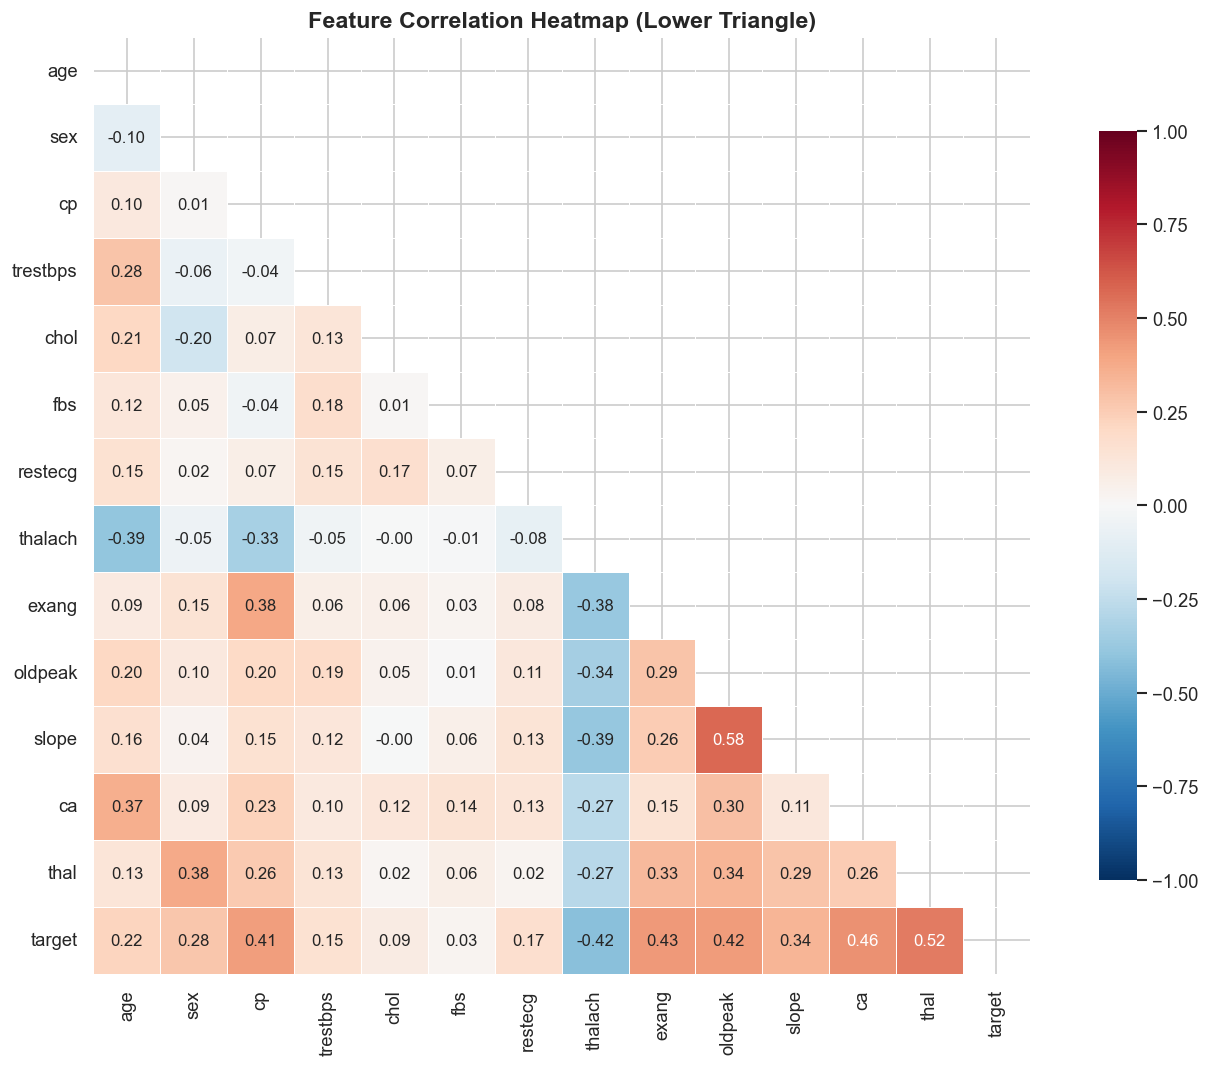


Top Correlations with Target:
  thal        : +0.522  (Strong)
  ca          : +0.460  (Strong)
  exang       : +0.432  (Strong)
  oldpeak     : +0.425  (Strong)
  thalach     : -0.417  (Strong)
  cp          : +0.414  (Strong)
  slope       : +0.339  (Strong)
  sex         : +0.277  (Moderate)
  age         : +0.223  (Moderate)
  restecg     : +0.169  (Weak)
  trestbps    : +0.151  (Weak)
  chol        : +0.085  (Weak)
  fbs         : +0.025  (Weak)


In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nTop Correlations with Target:")
print("=" * 40)
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = "+" if corr.loc[feat, 'target'] > 0 else "-"
    strength = "Strong" if val > 0.3 else "Moderate" if val > 0.2 else "Weak"
    print(f"  {feat:12s}: {direction}{val:.3f}  ({strength})")

### 8.1 Pair Plot — Feature Relationships

Visualizing pairwise relationships among the top correlated continuous features.

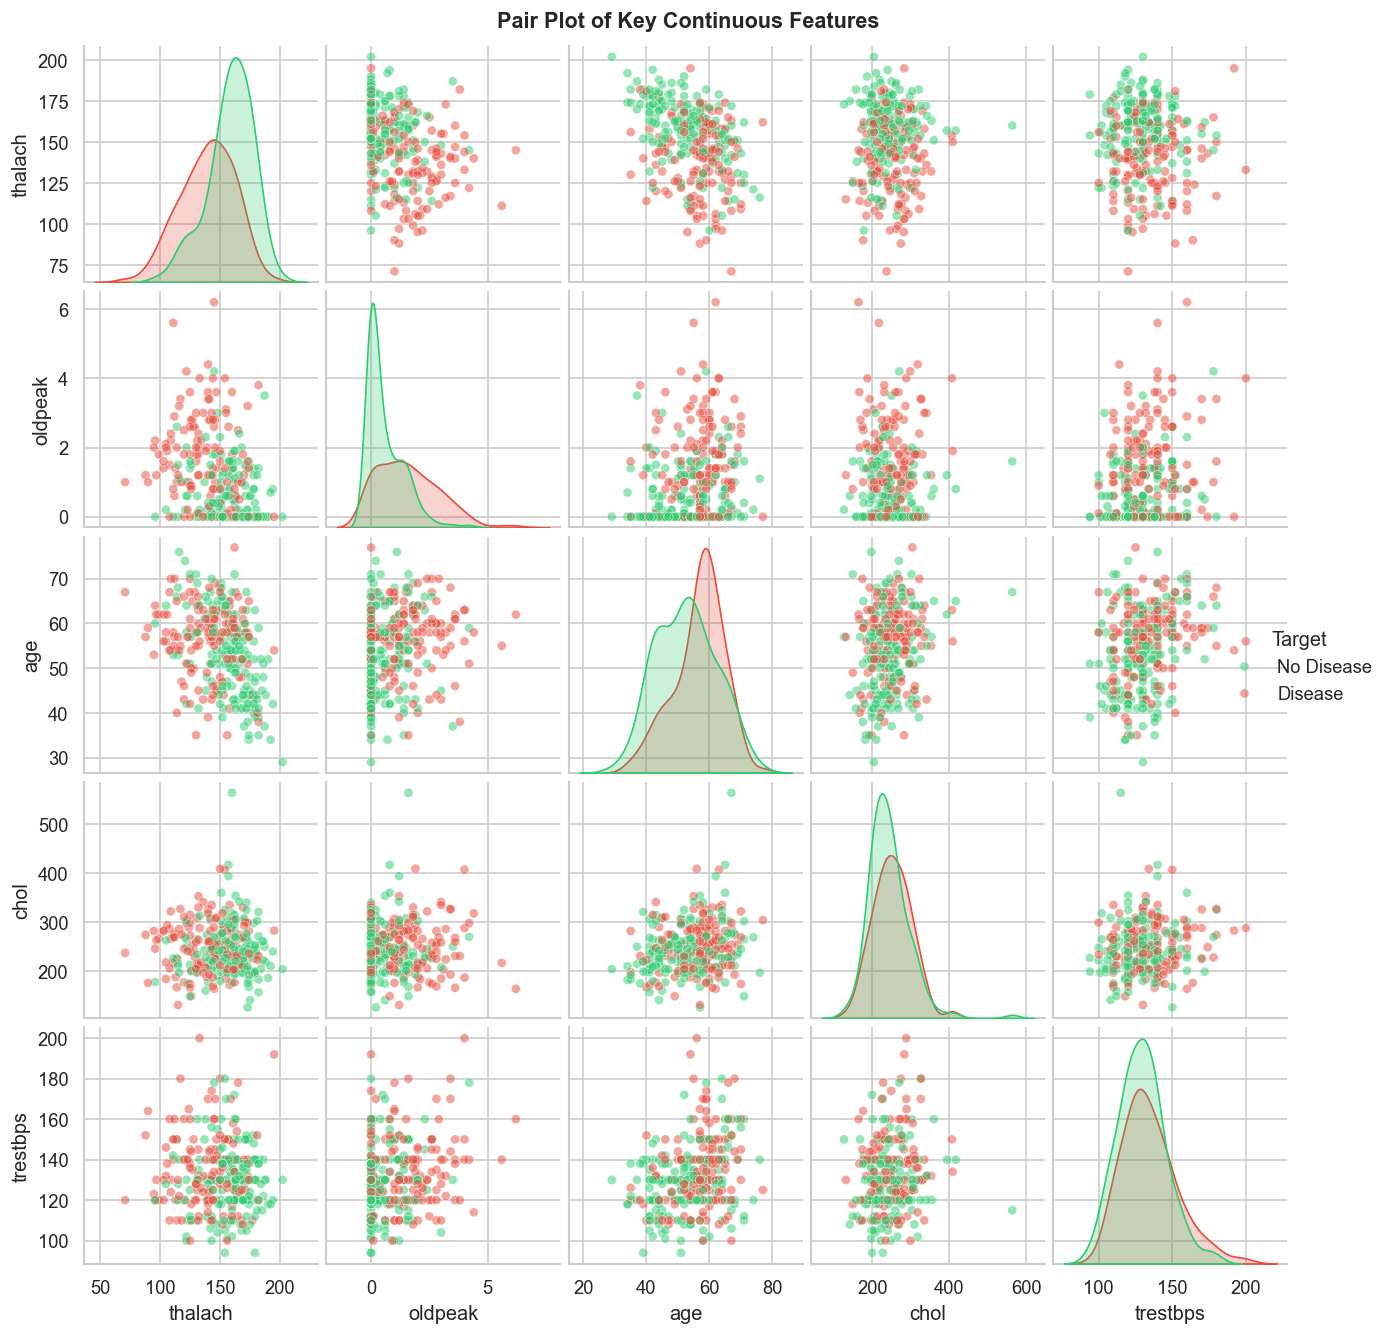

In [15]:
top_features = ['thalach', 'oldpeak', 'age', 'chol', 'trestbps']

g = sns.pairplot(df[top_features + ['target']], hue='target',
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 height=2.2, aspect=1)
g.figure.suptitle('Pair Plot of Key Continuous Features', y=1.01, fontsize=13, fontweight='bold')
g._legend.set_title('Target')
new_labels = ['No Disease', 'Disease']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.savefig('../screenshots/pairplot.png', bbox_inches='tight')
plt.show()

## 9. Box Plots — Outlier Detection

Identifying potential outliers in continuous features using the interquartile range (IQR) method.

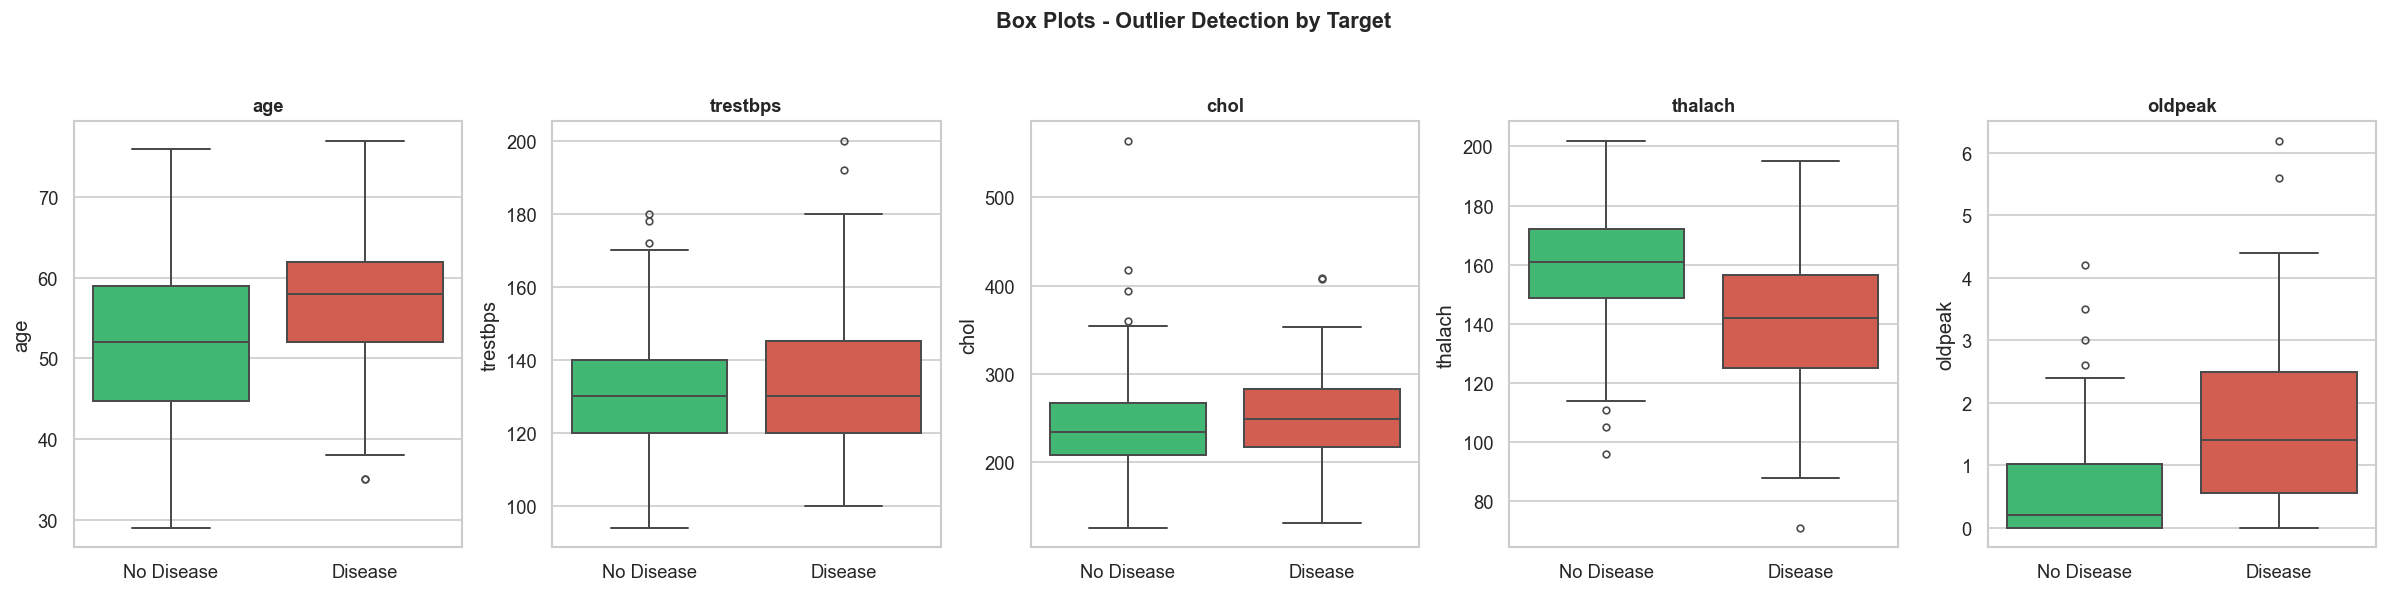

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(continuous_features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], hue='target',
                palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False,
                linewidth=1.2, flierprops={'marker': 'o', 'markersize': 4})
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Box Plots - Outlier Detection by Target', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../screenshots/boxplots.png', bbox_inches='tight')
plt.show()

In [17]:
print("Outlier Detection (IQR Method):")
print("=" * 60)
for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col:12s}: {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.1f}%)  "
          f"[Range: {lower:.1f} - {upper:.1f}]")

Outlier Detection (IQR Method):
  age         :   0 outliers (0.0%)  [Range: 28.5 - 80.5]
  trestbps    :   9 outliers (3.0%)  [Range: 90.0 - 170.0]
  chol        :   5 outliers (1.7%)  [Range: 115.0 - 371.0]
  thalach     :   1 outliers (0.3%)  [Range: 84.8 - 214.8]
  oldpeak     :   5 outliers (1.7%)  [Range: -2.4 - 4.0]


## 10. Feature Encoding Demonstration

Encoding categorical variables for model readiness. The dataset uses numeric codes,
but we demonstrate the mapping for interpretability and verify proper encoding.

In [18]:
binary_features = ['sex', 'fbs', 'exang']
ordinal_features = ['cp', 'restecg', 'slope', 'ca', 'thal']

print("Feature Type Summary:")
print("=" * 50)
print(f"\n  Binary Features ({len(binary_features)}): {binary_features}")
print(f"  Ordinal/Categorical Features ({len(ordinal_features)}): {ordinal_features}")
print(f"  Continuous Features ({len(continuous_features)}): {continuous_features}")

print("\n\nUnique values per categorical feature:")
print("-" * 50)
for col in binary_features + ordinal_features:
    unique_vals = sorted(df[col].unique())
    print(f"  {col:12s}: {unique_vals}")

for col in binary_features:
    df[col] = df[col].astype(int)

print("\n\nAll features are numeric and model-ready.")
print(f"Final dataset shape: {df.shape}")
print(f"\nFeature dtypes after encoding:")
print(df.dtypes)

Feature Type Summary:

  Binary Features (3): ['sex', 'fbs', 'exang']
  Ordinal/Categorical Features (5): ['cp', 'restecg', 'slope', 'ca', 'thal']
  Continuous Features (5): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


Unique values per categorical feature:
--------------------------------------------------
  sex         : [np.float64(0.0), np.float64(1.0)]
  fbs         : [np.float64(0.0), np.float64(1.0)]
  exang       : [np.float64(0.0), np.float64(1.0)]
  cp          : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  restecg     : [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
  slope       : [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  ca          : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  thal        : [np.float64(3.0), np.float64(6.0), np.float64(7.0)]


All features are numeric and model-ready.
Final dataset shape: (303, 14)

Feature dtypes after encoding:
age         float64
sex           int64
cp        

## 11. Age Group Analysis

Examining disease prevalence across age brackets for clinical interpretation.

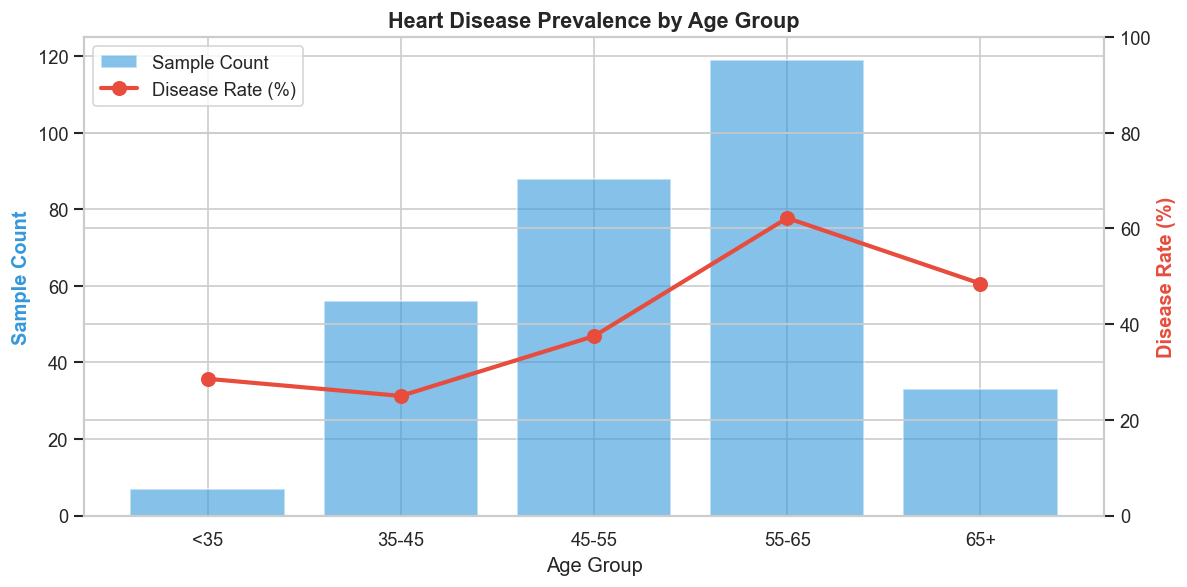

In [19]:
df['age_group'] = pd.cut(df['age'], bins=[20, 35, 45, 55, 65, 80],
                         labels=['<35', '35-45', '45-55', '55-65', '65+'])

age_disease = df.groupby('age_group', observed=True)['target'].agg(['mean', 'count']).reset_index()
age_disease.columns = ['Age Group', 'Disease Rate', 'Count']

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(age_disease['Age Group'], age_disease['Count'], color='#3498db', alpha=0.6,
               label='Sample Count', edgecolor='white')
ax1.set_ylabel('Sample Count', color='#3498db', fontweight='bold')
ax1.set_xlabel('Age Group')

ax2 = ax1.twinx()
ax2.plot(age_disease['Age Group'], age_disease['Disease Rate'] * 100, 'o-',
         color='#e74c3c', linewidth=2.5, markersize=8, label='Disease Rate (%)')
ax2.set_ylabel('Disease Rate (%)', color='#e74c3c', fontweight='bold')
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Heart Disease Prevalence by Age Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../screenshots/age_group_analysis.png', bbox_inches='tight')
plt.show()

df.drop('age_group', axis=1, inplace=True)

## 12. Gender-Based Analysis

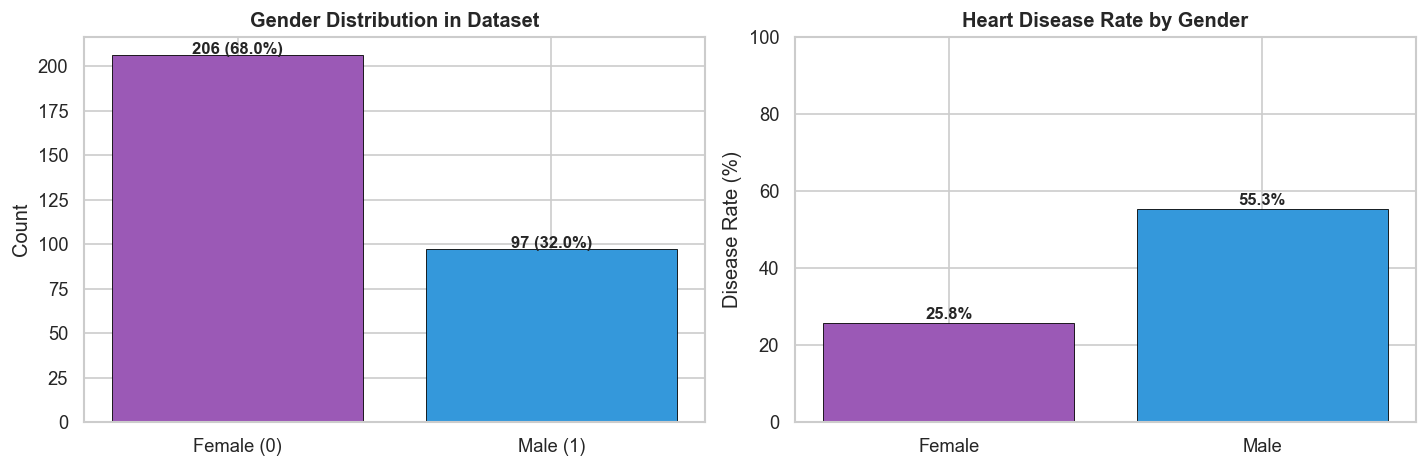

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_counts = df['sex'].value_counts()
axes[0].bar(['Female (0)', 'Male (1)'], gender_counts.values,
            color=['#9b59b6', '#3498db'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Gender Distribution in Dataset', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

gender_disease = df.groupby('sex')['target'].mean() * 100
bars = axes[1].bar(['Female', 'Male'], gender_disease.values,
                   color=['#9b59b6', '#3498db'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Heart Disease Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Disease Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(gender_disease.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/gender_analysis.png', bbox_inches='tight')
plt.show()

## 13. Key EDA Findings & Insights for Modeling

### Data Quality
- **Shape:** 303 samples x 14 features (13 predictors + 1 binary target)
- **Missing Values:** Only 6 values missing (in `ca` and `thal`) - handled with median imputation
- **Duplicates:** Minimal or none - dataset is clean
- **No data leakage** concerns identified

### Class Balance
- The dataset is **approximately balanced** (~54% No Disease, ~46% Disease)
- No resampling techniques are needed for initial modeling

### Key Discriminating Features (for Model Development)
1. **`cp` (Chest Pain Type):** Strongest categorical predictor - asymptomatic chest pain (type 4) is highly associated with disease
2. **`thalach` (Max Heart Rate):** Patients with disease tend to have **lower** max heart rates - clear separation in distributions
3. **`oldpeak` (ST Depression):** Higher values correlate with disease presence - right-skewed distribution
4. **`exang` (Exercise Angina):** Binary feature with strong predictive power
5. **`slope`:** Flat/downsloping ST segment strongly associated with disease
6. **`ca` (Number of Vessels):** More colored vessels = higher disease probability

### Observations for Feature Engineering
- **Skewness:** `oldpeak` and `ca` are right-skewed - consider log transformation
- **Outliers:** Present in `chol` and `trestbps` - robust scaling may be beneficial
- **Feature Scaling:** Continuous features have different ranges - StandardScaler recommended
- **All features are already numeric** - no one-hot encoding needed

### Recommended Modeling Approach
- Start with **Logistic Regression** (interpretable baseline) and **Random Forest** (handles non-linearity)
- Use **5-fold cross-validation** with ROC-AUC as primary metric
- Apply **StandardScaler** for Logistic Regression
- Evaluate with **precision, recall, F1, and ROC-AUC** given the medical domain importance of both false positives and false negatives

In [21]:
print("=" * 60)
print("EDA COMPLETE - Dataset is clean and ready for modeling")
print("=" * 60)
print(f"\n  Final Shape:    {df.shape}")
print(f"  Target Balance: {df['target'].value_counts().to_dict()}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Feature Types:  {len(continuous_features)} continuous, {len(binary_features)} binary, {len(ordinal_features)} ordinal")
print(f"\n  Next Steps:")
print(f"    -> Feature scaling (StandardScaler)")
print(f"    -> Model training (Logistic Regression + Random Forest)")
print(f"    -> Experiment tracking with MLflow")
print(f"    -> Cross-validation evaluation")

EDA COMPLETE - Dataset is clean and ready for modeling

  Final Shape:    (303, 14)
  Target Balance: {0: 164, 1: 139}
  Missing Values: 0
  Feature Types:  5 continuous, 3 binary, 5 ordinal

  Next Steps:
    -> Feature scaling (StandardScaler)
    -> Model training (Logistic Regression + Random Forest)
    -> Experiment tracking with MLflow
    -> Cross-validation evaluation
